In [1]:
import matplotlib.pyplot as plt
import numpy as np

from utils.utils import (fast_down_sample, fast_up_sample, 
                         make_image_collection, read_image_collection,
                         read_config, 
                         class_to_artificial, artificial_to_rgb, 
                         class_to_vegetal, vegetal_to_rgb,
                         class_to_rgb,
                         fast_down_sample, fast_up_sample)

from pprint import pprint
from pathlib import Path

In [2]:
# massage this to get the correct project root path (e.g. /../xxxx/myProjectName/)
root_dir = Path().resolve().parents[0]
conf = read_config(file_path=root_dir / 'config' /'config.yml', root_dir=root_dir) 


Configuration read from /workspaces/flairimages/config/config.yml
file locations are:
{'config': PosixPath('/workspaces/flairimages/config'),
 'dataset': PosixPath('/workspaces/flairimages/data/test'),
 'files_csv': PosixPath('/workspaces/flairimages/data/test/testdataset.csv'),
 'files_df': PosixPath('/workspaces/flairimages/data/test/testdataset.pkl'),
 'image_collection': PosixPath('/workspaces/flairimages/data/test/testimagecollection.npy'),
 'image_collection_index': PosixPath('/workspaces/flairimages/data/test/testimagecollectionindex.npy'),
 'metadata': PosixPath('/workspaces/flairimages/data/flair-1_metadata_aerial.json'),
 'outputs': PosixPath('/workspaces/flairimages/outputs')}


In [3]:
# format float to string with a thousands separator

print(f"expected memory usage: {1000000:,.0f} mb") 

expected memory usage: 1,000,000 mb


In [6]:
images, image_indices = make_image_collection(conf=conf,  max=10, sample=False)

Reading 10 images
Images will be downsampled by 8
Collection will be stored in shape (10, 64, 64, 6)
expected memory usage: 0 megabytes
Reading image 0 of 10
Image collection written to /workspaces/flairimages/data/test/testimagecollection.npy
Image collection indexes written to /workspaces/flairimages/data/test/testimagecollectionindex.npy


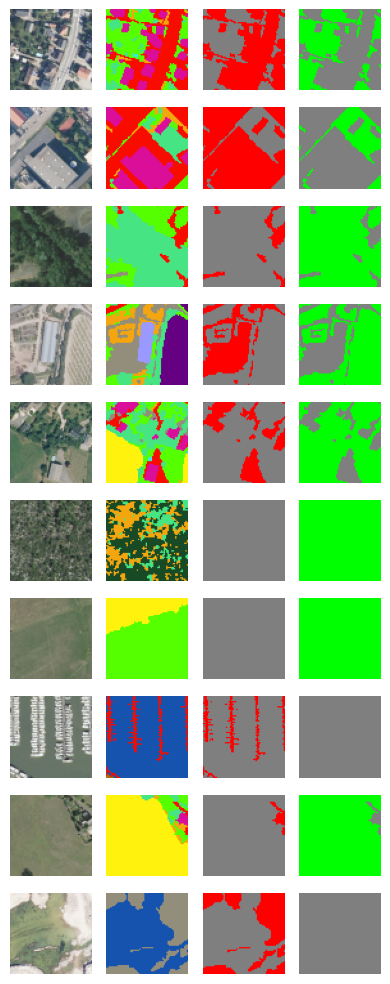

In [4]:
res = read_image_collection(conf=conf)

plt.figure(figsize=(4,10))
for i in range(10):
    img= res[i,:,:,:3]
    msk = res[i,:,:,-1]
    plt.subplot(10, 4, 4*i+1)
    plt.axis('off')
    plt.imshow(img)
    #
    plt.subplot(10, 4, 4*i+2)
    plt.axis('off')
    plt.imshow(class_to_rgb(arr=msk,config=conf))
    
    plt.subplot(10, 4, 4*i+3)
    plt.axis('off')
    plt.imshow(artificial_to_rgb(arr=class_to_artificial(arr=msk, conf=conf), conf=conf))
    
    plt.subplot(10, 4, 4*i+4)
    plt.axis('off')
    plt.imshow(vegetal_to_rgb(arr=class_to_vegetal(arr=msk, conf=conf), conf=conf))
    
    plt.tight_layout()
    

In [5]:
# print memory usage
print(res.shape)
print(res.nbytes/1e6*15000/10)


(100, 64, 64, 6)
3686.4
